In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import random
np.random.seed(42)
random.seed(42)

In [2]:
df = pd.read_excel('Bankruptcy.xlsx')
df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,non-bankruptcy
246,1.0,1.0,0.5,1.0,1.0,0.0,non-bankruptcy
247,0.0,1.0,1.0,0.5,0.5,0.0,non-bankruptcy
248,1.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy


In [3]:
df.head()    #preview first few rows

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy


In [4]:
df.shape     #rows & column

(250, 7)

In [5]:
df.info()      #column types & missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [6]:
df.describe()        #statistical info

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.518000,0.614000,0.376000,0.470000,0.476000,0.570000
std,0.411526,0.410705,0.401583,0.415682,0.440682,0.434575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
#Make all column names consistent (lowercase, no spaces, underscores instead of spaces).
#Avoid problems like “Financial Flexibility” vs “financial_flexibility”.
#Clean columns for easier coding later.

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns


Index(['industrial_risk', 'management_risk', 'financial_flexibility',
       'credibility', 'competitiveness', 'operating_risk', 'class'],
      dtype='object')

In [8]:
#Remove Duplicates

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicate rows: 147


In [9]:
duplicates = df[df.duplicated()]
duplicates.head(10)


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class


In [10]:
df = df.drop_duplicates()
print("Duplicates removed successfully!")
print("New shape after removing duplicates:", df.shape)


Duplicates removed successfully!
New shape after removing duplicates: (103, 7)


In [11]:
print("Duplicate rows after cleaning:", df.duplicated().sum())


Duplicate rows after cleaning: 0


In [12]:
#handle the missing values
df.isna().sum()


industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

In [13]:
df = df.fillna(df.median(numeric_only=True))



In [14]:
missing_ratio = df.isna().mean() * 100
cols_to_drop = missing_ratio[missing_ratio > 40].index
df = df.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)


Dropped columns: Index([], dtype='object')


In [15]:
df.select_dtypes(include=['object']).columns


Index(['class'], dtype='object')

In [16]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded: {col}")


Encoded: class


In [17]:
#handling outliers

df.describe().T


,count,mean,std,min,25%,50%,75%,max
industrial_risk,103.0,0.485437,0.404971,0.0,0.0,0.5,1.0,1.0
management_risk,103.0,0.563107,0.412308,0.0,0.0,0.5,1.0,1.0
financial_flexibility,103.0,0.504854,0.405206,0.0,0.0,0.5,1.0,1.0
credibility,103.0,0.582524,0.377668,0.0,0.5,0.5,1.0,1.0
competitiveness,103.0,0.640777,0.410747,0.0,0.5,1.0,1.0,1.0
operating_risk,103.0,0.514563,0.439788,0.0,0.0,0.5,1.0,1.0
class,103.0,0.757282,0.430823,0.0,1.0,1.0,1.0,1.0


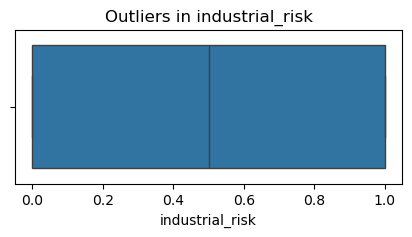

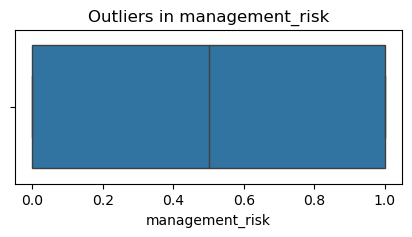

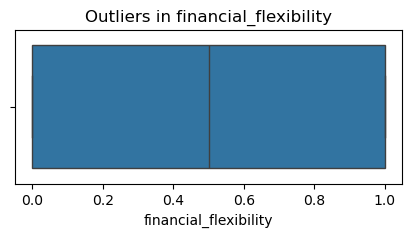

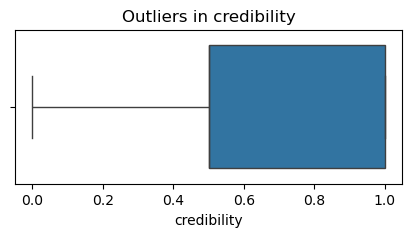

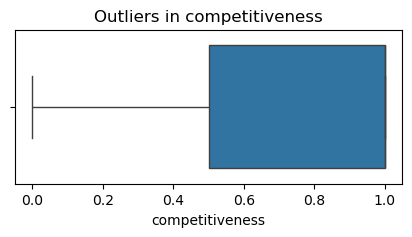

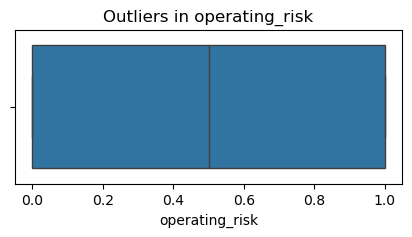

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


In [19]:
# Winsorization (cap extreme values)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    q1 = df[col].quantile(0.05)
    q3 = df[col].quantile(0.95)
    df[col] = df[col].clip(lower=q1, upper=q3)


In [20]:
#checking data consistency
(df < 0).sum()


industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

In [21]:
#checking the cleaned data set

print("Final shape:", df.shape)
print(df.info())
print(df.describe().T)


Final shape: (103, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 0 to 194
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        103 non-null    float64
 1   management_risk        103 non-null    float64
 2   financial_flexibility  103 non-null    float64
 3   credibility            103 non-null    float64
 4   competitiveness        103 non-null    float64
 5   operating_risk         103 non-null    float64
 6   class                  103 non-null    int32  
dtypes: float64(6), int32(1)
memory usage: 6.0 KB
None
                       count      mean       std  min  25%  50%  75%  max
industrial_risk        103.0  0.485437  0.404971  0.0  0.0  0.5  1.0  1.0
management_risk        103.0  0.563107  0.412308  0.0  0.0  0.5  1.0  1.0
financial_flexibility  103.0  0.504854  0.405206  0.0  0.0  0.5  1.0  1.0
credibility            103.0  0.582524  0.377668  0.0  0.5  

In [22]:
## check if any missing values remain
print("\nMissing values before Imputation:")
print(df.isnull().sum())


Missing values before Imputation:
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64


In [23]:
### checking Mean Imputation
## Replace missing numeric values  with the mean of each column
df_mean= df.copy()
df_mean.fillna(df_mean.mean(numeric_only=True), inplace=True)

In [24]:
### checking Median Imputation
## Replace missing numeric values  with the median of each column
df_median= df.copy()
df_median.fillna(df_median.median(numeric_only=True), inplace=True)

In [25]:
### checking Mode Imputation
## Replace missing numeric values  with the mode of each column
df_mode= df.copy()
df_mode.fillna(df_mode.mode(numeric_only=True), inplace=True)

In [26]:
## Forward fill Imputation technique
# Fills missing values using the previous row's value
df_ffill= df.copy()
df_ffill.fillna(method='ffill', inplace=True)

In [27]:
## Backward fill Imputation technique
# Fills missing values using the next row's value
df_bfill= df.copy()
df_bfill.fillna(method='bfill', inplace=True)

In [28]:
# check Missing Values After Imputation
print("\nMissing values After Mean Imputation :")
print(df_mean.isnull().sum())


Missing values After Mean Imputation :
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64


Target Variable Distribution

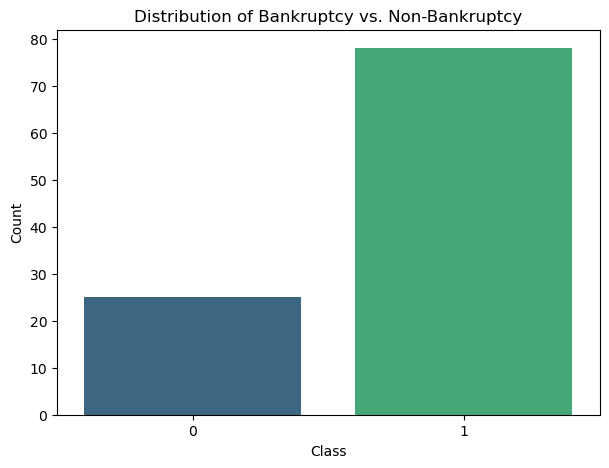

--- Class Value Counts ---
class
1    78
0    25
Name: count, dtype: int64

--- Class Proportions ---
class
1    75.73%
0    24.27%
Name: proportion, dtype: object


In [29]:
# Check the distribution of the target variable 'class'
plt.figure(figsize=(7, 5))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of Bankruptcy vs. Non-Bankruptcy')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Print the value counts to see the exact numbers
print("--- Class Value Counts ---")
print(df['class'].value_counts())
print("\n--- Class Proportions ---")
print(df['class'].value_counts(normalize=True).map('{:.2%}'.format))

Univariate Feature Distributions

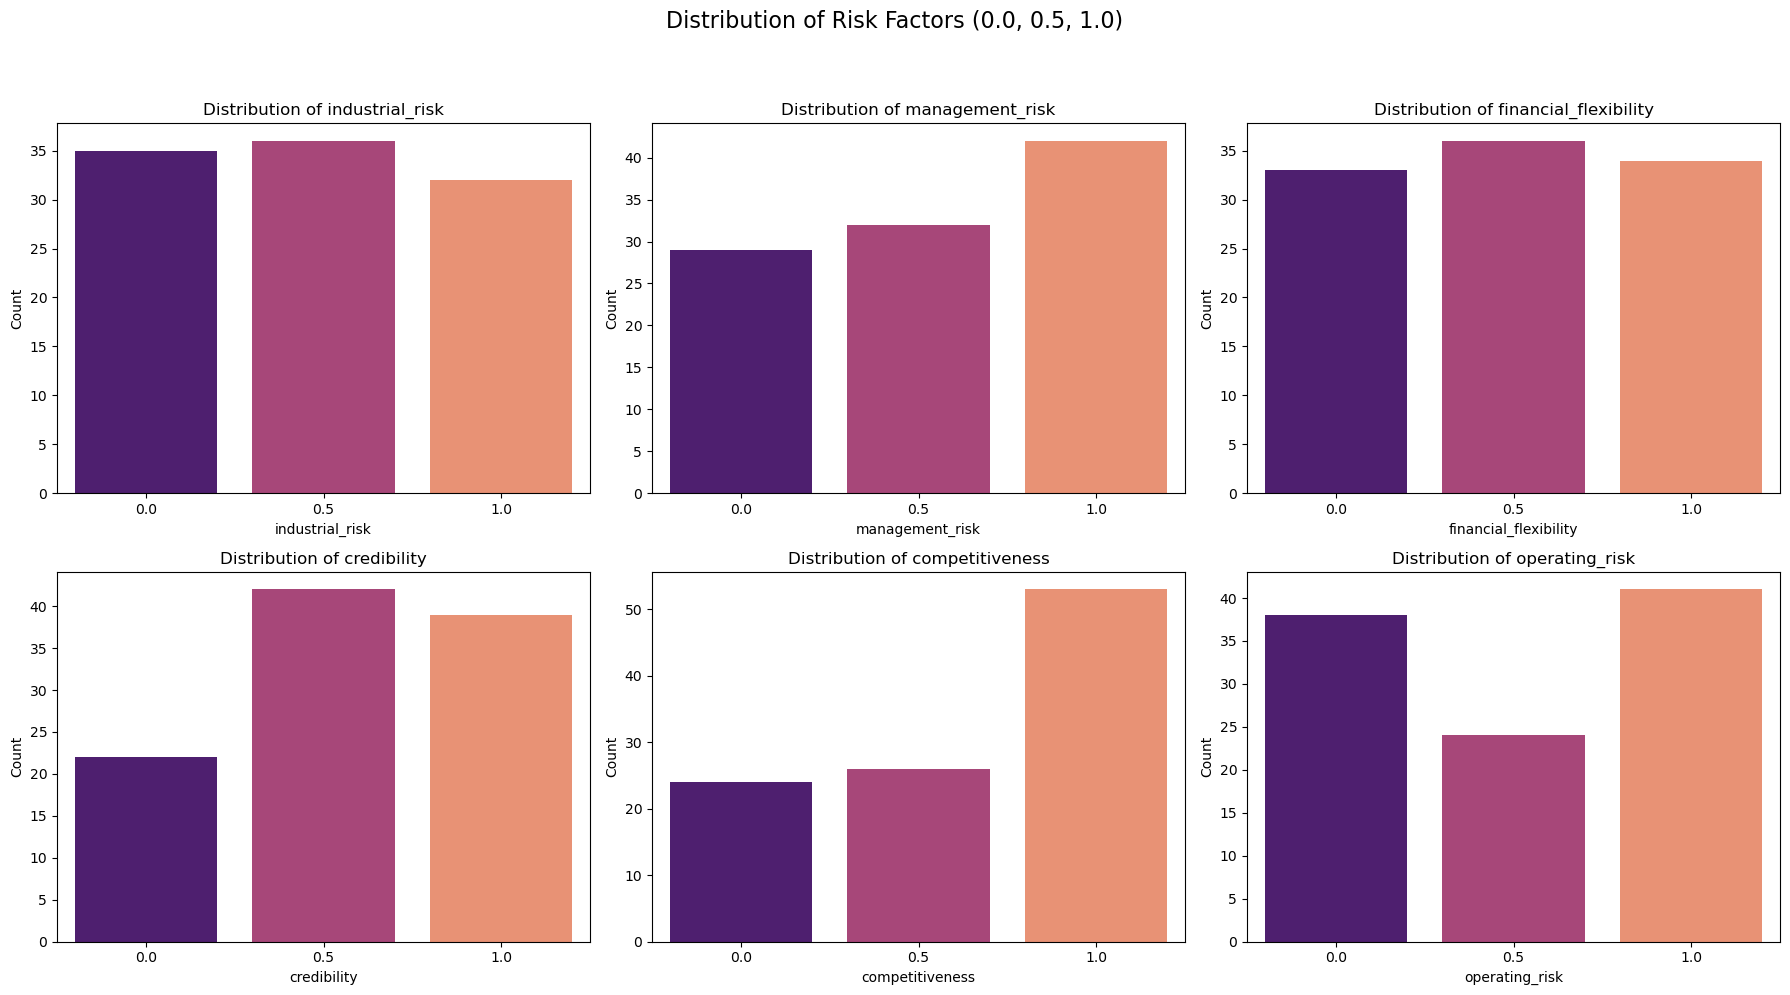

In [30]:
# List of all feature columns (excluding the target 'class')
feature_cols = df.columns.drop('class')

# Create a figure and axes for the subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flattens the 2x3 grid into a 1D array for easy iteration

plt.suptitle('Distribution of Risk Factors (0.0, 0.5, 1.0)', fontsize=16, y=1.02)

for i, col in enumerate(feature_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

Feature Relationship with Target Variable

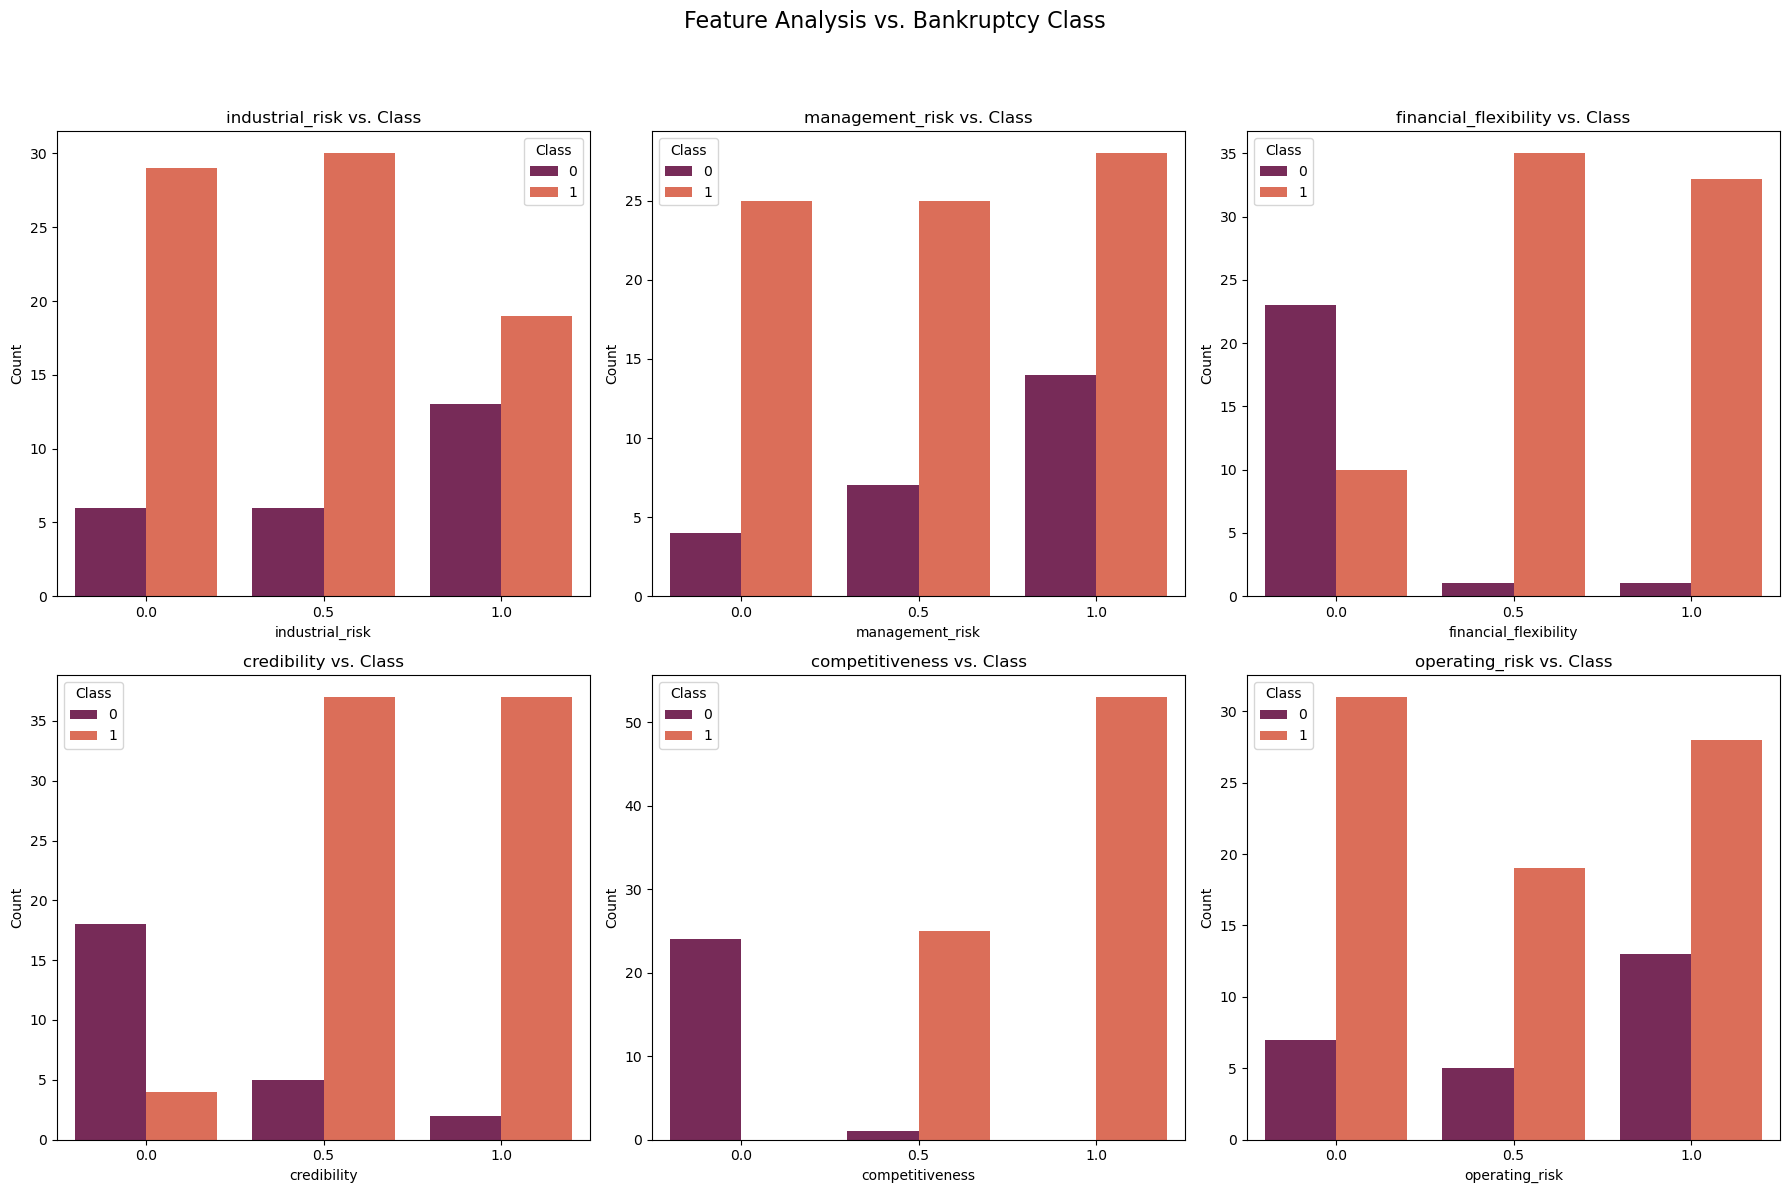

In [31]:
# Analyze relationship between features and the target variable 'class'

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plt.suptitle('Feature Analysis vs. Bankruptcy Class', fontsize=16, y=1.02)

for i, col in enumerate(feature_cols):
    # Use hue='class' to show the breakdown by bankruptcy status
    sns.countplot(x=col, hue='class', data=df, ax=axes[i], palette='rocket')
    axes[i].set_title(f'{col} vs. Class', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Class')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Correlation Analysis

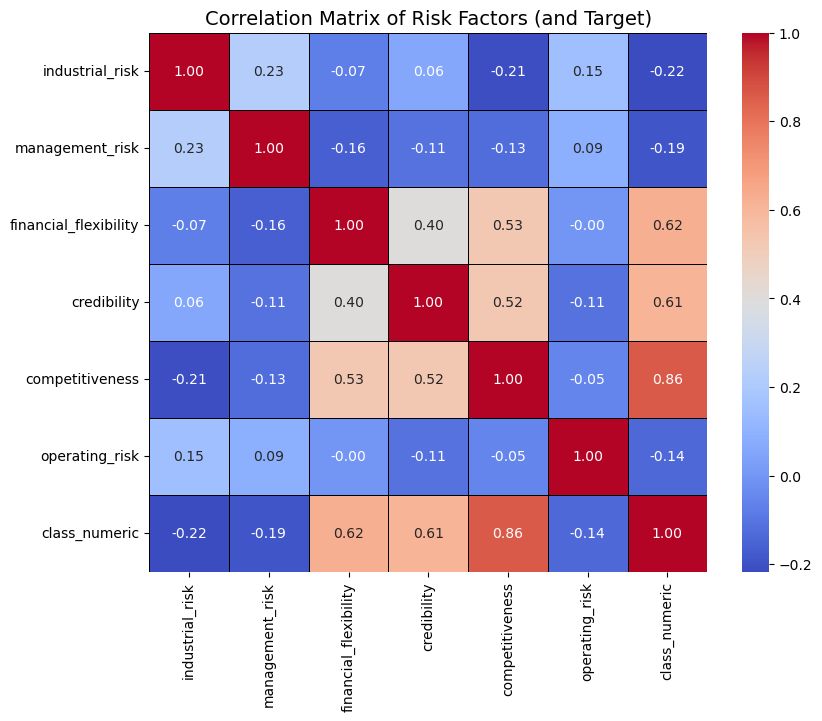

In [32]:
# Convert the target variable to numerical for correlation calculation (0 for non-bankruptcy, 1 for bankruptcy)
df_corr = df.copy()
df_corr['class_numeric'] = df_corr['class'].replace({'non-bankruptcy': 0, 'bankruptcy': 1})

# Calculate the correlation matrix
correlation_matrix = df_corr.drop('class', axis=1).corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix,
            annot=True,        # Show correlation values on the map
            fmt=".2f",         # Format the values to 2 decimal places
            cmap='coolwarm',   # Color map
            linewidths=.5,     # Lines between cells
            linecolor='black')
plt.title('Correlation Matrix of Risk Factors (and Target)', fontsize=14)
plt.show()

**DATA TRANSFORMATION**

Transformation makes the data ready for modeling — it ensures all features are in a comparable scale and suitable format for ML algorithms.

In [33]:
# Encode categorical columns (if any)

from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

print("Categorical features encoded successfully.")
df.head()


Categorical features encoded successfully.


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0
2,1.0,0.0,0.0,0.0,0.0,1.0,0
3,0.5,0.0,0.0,0.5,0.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,0


In [34]:
# Scaling numerical features

from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.drop(columns=['class'])),
                         columns=df.drop(columns=['class']).columns)
df_scaled['class'] = df['class']
print("Numerical features scaled successfully.")
df_scaled.head()




Numerical features scaled successfully.


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.036137,1.064809,-1.252013,-1.549969,-1.567656,-0.033276,0.0
1,-1.204557,1.064809,-1.252013,-1.549969,-1.567656,1.109196,0.0
2,1.276830,-1.372421,-1.252013,-1.549969,-1.567656,1.109196,0.0
3,0.036137,-1.372421,-1.252013,-0.219579,-1.567656,1.109196,0.0
4,1.276830,1.064809,-1.252013,-1.549969,-1.567656,1.109196,0.0


In [35]:
# Log Transformation (if skewed data)
# If any feature has highly skewed distribution, apply log transformation to make it more normal.
#Check skewness

print(df_scaled.skew())

industrial_risk          0.053615
management_risk         -0.240163
financial_flexibility   -0.017869
credibility             -0.284848
competitiveness         -0.567021
operating_risk          -0.057269
class                    0.000000
dtype: float64


In [36]:
# Apply log transformation for skewed features (skip if all are between 0–1)

for col in df_scaled.columns[:-1]:
    if abs(df_scaled[col].skew()) > 1:
        df_scaled[col] = np.log1p(df_scaled[col])
        print(f"Applied log transformation on {col}")

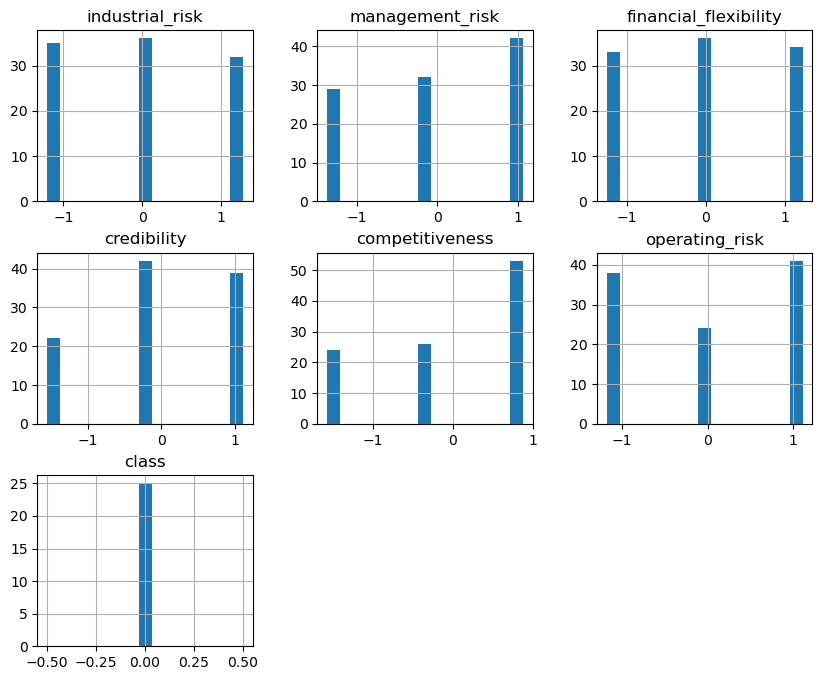

In [37]:
# check again after transformation
df_scaled.hist(figsize=(10, 8), bins=15)
plt.show()

**DATA PREPROCESSING**

In [38]:
# Quick look at the data

print("Shape:", df.shape)
display(df.head())



Shape: (103, 7)


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0
2,1.0,0.0,0.0,0.0,0.0,1.0,0
3,0.5,0.0,0.0,0.5,0.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,0


In [39]:
# Info & basic stats

df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 0 to 194
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        103 non-null    float64
 1   management_risk        103 non-null    float64
 2   financial_flexibility  103 non-null    float64
 3   credibility            103 non-null    float64
 4   competitiveness        103 non-null    float64
 5   operating_risk         103 non-null    float64
 6   class                  103 non-null    int32  
dtypes: float64(6), int32(1)
memory usage: 10.1 KB


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,0.485437,0.563107,0.504854,0.582524,0.640777,0.514563,0.757282
std,0.404971,0.412308,0.405206,0.377668,0.410747,0.439788,0.430823
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.500000,0.500000,0.000000,1.000000
50%,0.500000,0.500000,0.500000,0.500000,1.000000,0.500000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Handle Duplicates and Missing Values

In [40]:
# Remove duplicate rows

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
df = df.drop_duplicates()

Duplicate rows: 0


In [41]:
# Handle missing values (if any)

print("Missing values before:")
print(df.isnull().sum())

Missing values before:
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64


In [42]:
# Fill missing numeric values with mean, categorical with mode

for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after:")
print(df.isnull().sum())

Missing values after:
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64


Encode Categorical Columns

In [43]:
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

print("Categorical columns encoded.")
display(df.head())

Categorical columns encoded.


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0
2,1.0,0.0,0.0,0.0,0.0,1.0,0
3,0.5,0.0,0.0,0.5,0.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,0


In [44]:
# scale numerical feature

scaler = StandardScaler()
X = df.drop(columns=['class'])
y = df['class']

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
df_scaled = pd.concat([X_scaled, y], axis=1)

print("Data scaled successfully.")
display(df_scaled.head())

Data scaled successfully.


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.036137,1.064809,-1.252013,-1.549969,-1.567656,-0.033276,0.0
1,-1.204557,1.064809,-1.252013,-1.549969,-1.567656,1.109196,0.0
2,1.276830,-1.372421,-1.252013,-1.549969,-1.567656,1.109196,0.0
3,0.036137,-1.372421,-1.252013,-0.219579,-1.567656,1.109196,0.0
4,1.276830,1.064809,-1.252013,-1.549969,-1.567656,1.109196,0.0


Detect and Treat Outliers

In [45]:
#We’ll use the IQR (Interquartile Range) method.

Q1 = df_scaled.quantile(0.25)
Q3 = df_scaled.quantile(0.75)
IQR = Q3 - Q1


In [46]:
# Detect outliers

outliers = ((df_scaled < (Q1 - 1.5 * IQR)) | (df_scaled > (Q3 + 1.5 * IQR)))
print("Outliers detected per feature:")
print(outliers.sum())


Outliers detected per feature:
industrial_risk           0
management_risk           0
financial_flexibility     0
credibility               0
competitiveness           0
operating_risk            0
class                    25
dtype: int64


In [47]:
# Cap or remove outliers (here: capping)

for col in df_scaled.columns[:-1]:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_scaled[col] = np.where(df_scaled[col] < lower, lower, df_scaled[col])
    df_scaled[col] = np.where(df_scaled[col] > upper, upper, df_scaled[col])

print("Outliers capped successfully.")

Outliers capped successfully.


Feature Selection

We’ll use multiple techniques — correlation, statistical tests, and model-based importance.

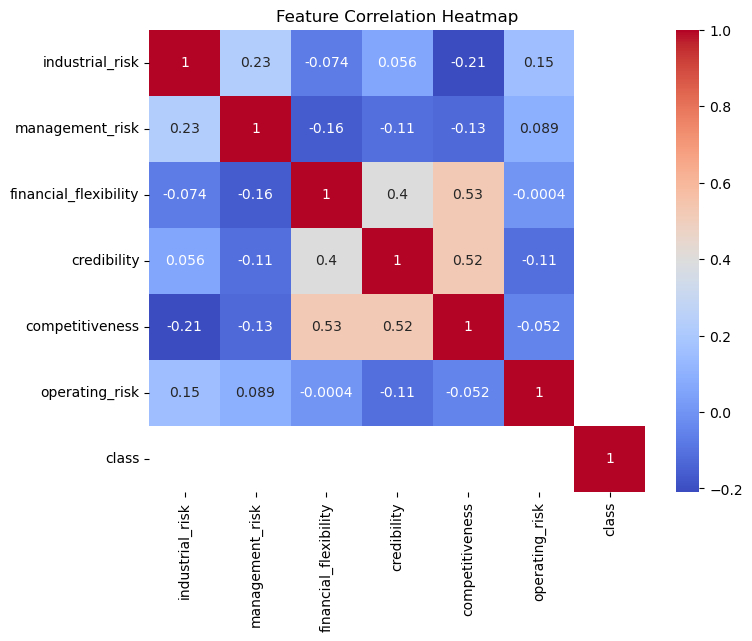

In [48]:
#Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [49]:
#Statistical Feature Selection

from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
X = df_scaled.drop(columns=['class'])
y = df_scaled['class']


In [50]:
# Check for NaNs in each column
print(X.isna().sum())

# Remove all rows with any NaNs
X_no_nan = X.dropna()

# If you have a corresponding y, keep only matching rows
y_no_nan = y.loc[X_no_nan.index]

# Confirm no NaNs remain
print(X_no_nan.isna().sum())


industrial_risk          78
management_risk          78
financial_flexibility    78
credibility              78
competitiveness          78
operating_risk           78
dtype: int64
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
dtype: int64


In [51]:
# Remove rows where y is NaN
not_nan_idx = y.notna()
y_no_nan = y.loc[not_nan_idx]
X_aligned = X.loc[not_nan_idx]

# Confirm no NaNs remain in y
print(y_no_nan.isna().sum())


0


In [52]:
# Check if there are any NaNs
print("Any NaNs in X?", X.isna().any().any())
print("Any NaNs in y?", y.isna().any())


Any NaNs in X? True
Any NaNs in y? True


In [53]:
# Keep only rows where neither X nor y has NaN
not_nan_idx = X.notna().all(axis=1) & y.notna()
X_clean = X.loc[not_nan_idx]
y_clean = y.loc[not_nan_idx]

# Verify
print("Any NaNs in X_clean?", X_clean.isna().any().any())
print("Any NaNs in y_clean?", y_clean.isna().any())


Any NaNs in X_clean? False
Any NaNs in y_clean? False


In [54]:
print(y[y.isna()])   #This will show you the missing targets, so you can decide whether to drop them.


11    NaN
13    NaN
15    NaN
16    NaN
18    NaN
       ..
98    NaN
99    NaN
100   NaN
101   NaN
102   NaN
Name: class, Length: 78, dtype: float64


Since almost 78 rows are missing y, we should:

Drop rows where y is NaN.

Impute missing values in X if needed (e.g., fill NaN with 0 or mean).

In [55]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2

# 1. Drop rows where y is NaN

not_nan_idx = y.notna()
X_clean = X.loc[not_nan_idx]
y_clean = y.loc[not_nan_idx]


In [56]:
# 2. Impute missing values in X

imputer = SimpleImputer(strategy='constant', fill_value=0)
X_imputed = pd.DataFrame(imputer.fit_transform(X_clean.abs()), columns=X_clean.columns)

In [57]:
# 3. Apply Chi2

chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_imputed, y_clean)

SelectKBest(k='all', score_func=<function chi2 at 0x00000204342CB4C0>)

In [58]:
# 4. Get scores

chi2_scores = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Chi2": chi2_selector.scores_
}).sort_values(by="Chi2", ascending=False)

chi2_scores

,Feature,Chi2
4,competitiveness,96.747187
2,financial_flexibility,81.956763
3,credibility,79.429687
1,management_risk,79.363778
0,industrial_risk,78.434008
5,operating_risk,68.037173


In [59]:
not_nan_idx = y.notna()
X_clean = X.loc[not_nan_idx]
y_clean = y.loc[not_nan_idx]


In [60]:
X_imputed = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X_clean), columns=X_clean.columns)

In [61]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_imputed, y_clean)

f_scores = pd.DataFrame({
    "Feature": X_imputed.columns,
    "F_Score": f_selector.scores_
}).sort_values(by="F_Score", ascending=False)

f_scores


,Feature,F_Score
3,credibility,6.757758e-14
0,industrial_risk,3.010143e-15
1,management_risk,0.000000e+00
4,competitiveness,0.000000e+00
5,operating_risk,-9.217750e-16
2,financial_flexibility,-3.889600e-14


In [62]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd

# Drop rows with NaN in y

not_nan_idx = y.notna()
X_clean = X.loc[not_nan_idx]
y_clean = y.loc[not_nan_idx]

In [63]:
# Impute missing values in X (mean or 0)

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=X_clean.columns)

In [64]:
# Apply mutual information

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_imputed, y_clean)

SelectKBest(k='all',
            score_func=<function mutual_info_classif at 0x00000204342C9800>)

In [65]:
# Create a DataFrame of scores

mi_scores = pd.DataFrame({
    "Feature": X_imputed.columns,
    "MI_Score": mi_selector.scores_
}).sort_values(by="MI_Score", ascending=False)

mi_scores

,Feature,MI_Score
0,industrial_risk,0.559082
1,management_risk,0.559082
2,financial_flexibility,0.559082
3,credibility,0.559082
4,competitiveness,0.559082
5,operating_risk,0.559082


In [66]:
print("Feature selection scores calculated.")
display(chi2_scores)
display(f_scores)
display(mi_scores)

Feature selection scores calculated.


,Feature,Chi2
4,competitiveness,96.747187
2,financial_flexibility,81.956763
3,credibility,79.429687
1,management_risk,79.363778
0,industrial_risk,78.434008
5,operating_risk,68.037173


,Feature,F_Score
3,credibility,6.757758e-14
0,industrial_risk,3.010143e-15
1,management_risk,0.000000e+00
4,competitiveness,0.000000e+00
5,operating_risk,-9.217750e-16
2,financial_flexibility,-3.889600e-14


,Feature,MI_Score
0,industrial_risk,0.559082
1,management_risk,0.559082
2,financial_flexibility,0.559082
3,credibility,0.559082
4,competitiveness,0.559082
5,operating_risk,0.559082


In [67]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Drop rows with NaN in y

not_nan_idx = y.notna()
X_clean = X.loc[not_nan_idx]
y_clean = y.loc[not_nan_idx]

In [68]:
# Step 2: Impute missing values in X

imputer = SimpleImputer(strategy='mean')  # or 'median', 'constant', etc.
X_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=X_clean.columns)

In [69]:
# Step 3: Fit Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_imputed, y_clean)

RandomForestClassifier(random_state=42)

In [70]:
# Step 4: Get feature importances

importances = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

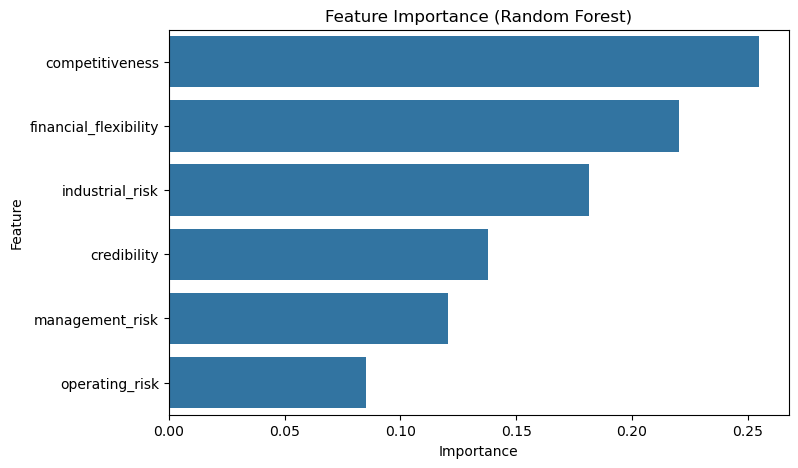

In [71]:
# Step 5: Plot

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

Select Top Features

In [72]:
top_features = importances["Feature"].head(4).tolist()
print("Top Selected Features:", top_features)

X_selected = X[top_features]
df_selected = pd.concat([X_selected, y], axis=1)

df_selected.to_excel("bankruptcy_preprocessed.xlsx", index=False)
print("Final preprocessed dataset saved as bankruptcy_preprocessed.xlsx")

Top Selected Features: ['competitiveness', 'financial_flexibility', 'industrial_risk', 'credibility']
Final preprocessed dataset saved as bankruptcy_preprocessed.xlsx


Check Multicollinearity using VIF (Variance Inflation Factor)

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Step 1: Impute missing values in X_selected

imputer = SimpleImputer(strategy='mean')  # or 'median', etc.
X_filled = pd.DataFrame(imputer.fit_transform(X_selected), columns=X_selected.columns)

In [74]:
# Step 2: Calculate VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = X_filled.columns
vif_data["VIF"] = [variance_inflation_factor(X_filled.values, i) for i in range(X_filled.shape[1])]

print("Variance Inflation Factor (VIF):")
display(vif_data)

Variance Inflation Factor (VIF):


,Feature,VIF
0,competitiveness,1.773629
1,financial_flexibility,1.422849
2,industrial_risk,1.088579
3,credibility,1.476052


Variance Inflation Factor (VIF) was calculated to detect multicollinearity among the selected features.
All VIF values were below 2, indicating no significant correlation among predictors.
Therefore, no features were removed, and the selected four features were retained for model training.

In [75]:
# Remove all rows with NaNs in X
X_no_nan = X.dropna()

# If you have a corresponding y, keep only matching rows
y_no_nan = y.loc[X_no_nan.index]


In [76]:
print(y.isna().sum())


78


Remove or impute missing target values:

Since y is the target variable, usually you drop rows with NaN targets rather than imputing them:

In [77]:
# Drop rows where y is NaN

mask = y.notna()
X = X[mask]
y = y[mask]

In [78]:
print(X.isna().sum())
print(y.isna().sum())


industrial_risk          78
management_risk          78
financial_flexibility    78
credibility              78
competitiveness          78
operating_risk           78
dtype: int64
0


In [79]:
# Drop rows with missing values in X or y
data = X.copy()
data['target'] = y
data = data.dropna()  # removes rows where X or y is NaN

# Separate back X and y
X_clean = data.drop('target', axis=1)
y_clean = data['target']


In [80]:
import numpy as np

print("Unique values in y:", np.unique(y))
print("Counts per class in y:", np.unique(y, return_counts=True))


Unique values in y: [0. 1.]
Counts per class in y: (array([0., 1.]), array([25, 78], dtype=int64))


In [81]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


print("Counts in y_train:", np.unique(y_train, return_counts=True))
print("Counts in y_test:", np.unique(y_test, return_counts=True))

Counts in y_train: (array([0., 1.]), array([20, 62], dtype=int64))
Counts in y_test: (array([0., 1.]), array([ 5, 16], dtype=int64))


In [82]:
print("Columns in dataset:", df.columns)


Columns in dataset: Index(['industrial_risk', 'management_risk', 'financial_flexibility',
       'credibility', 'competitiveness', 'operating_risk', 'class'],
      dtype='object')


In [83]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")


industrial_risk: [0.5 0.  1. ]
management_risk: [1.  0.  0.5]
financial_flexibility: [0.  0.5 1. ]
credibility: [0.  0.5 1. ]
competitiveness: [0.  0.5 1. ]
operating_risk: [0.5 1.  0. ]
class: [0 1]


In [84]:
# Correct target column
target_col = 'class'

# Prepare X and y
y = df[target_col]
X = df.drop(columns=[target_col])

# Drop rows where y is NaN
mask = ~y.isna()
X = X[mask]
y = y[mask]

# Verify target classes
print("Unique values in y:", np.unique(y))
print("Counts per class:", np.unique(y, return_counts=True))

# Check for at least 2 classes
if len(np.unique(y)) < 2:
    raise ValueError(f"The target column '{target_col}' has less than 2 classes. Cannot perform classification.")
else:
    print("Target column is valid for classification!")


Unique values in y: [0 1]
Counts per class: (array([0, 1]), array([25, 78], dtype=int64))
Target column is valid for classification!


**MODEL BUILDING**

model 1: Logistic regression

In [85]:
# Step 1: Imports

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
# Step 2: Handle missing values in features

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [87]:
# Step 3: Split & scale (train test split model)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

In [88]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((82, 6), (21, 6), (82,), (21,))

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [90]:
X_train_scaled

array([[ 1.27596711, -0.14920388,  1.15305917, -0.26375219, -1.55331305,
        -1.18895272],
       [-1.12930422,  1.07426796, -0.05913124, -0.26375219, -0.31669489,
         1.07835246],
       [-1.12930422, -1.37267573, -0.05913124, -0.26375219,  0.91992326,
        -1.18895272],
       [ 0.07333144, -0.14920388, -0.05913124, -0.26375219, -0.31669489,
        -0.05530013],
       [-1.12930422, -1.37267573,  1.15305917, -0.26375219,  0.91992326,
        -1.18895272],
       [ 0.07333144, -1.37267573, -1.27132165, -1.61548216, -1.55331305,
         1.07835246],
       [-1.12930422, -0.14920388,  1.15305917,  1.08797778,  0.91992326,
         1.07835246],
       [ 1.27596711, -1.37267573, -0.05913124, -0.26375219, -0.31669489,
         1.07835246],
       [ 1.27596711, -0.14920388, -1.27132165, -1.61548216, -1.55331305,
         1.07835246],
       [-1.12930422, -0.14920388, -1.27132165, -0.26375219,  0.91992326,
         1.07835246],
       [-1.12930422, -0.14920388,  1.15305917, -0.

In [91]:
X_test_scaled

array([[ 0.07333144, -0.14920388, -0.05913124, -0.26375219,  0.91992326,
        -0.05530013],
       [ 0.07333144, -1.37267573, -0.05913124, -0.26375219, -0.31669489,
        -1.18895272],
       [ 1.27596711, -1.37267573, -1.27132165,  1.08797778,  0.91992326,
        -0.05530013],
       [ 1.27596711,  1.07426796, -0.05913124,  1.08797778, -0.31669489,
         1.07835246],
       [ 0.07333144,  1.07426796, -1.27132165,  1.08797778,  0.91992326,
        -0.05530013],
       [ 0.07333144, -1.37267573,  1.15305917,  1.08797778,  0.91992326,
         1.07835246],
       [ 0.07333144, -0.14920388, -1.27132165,  1.08797778,  0.91992326,
        -1.18895272],
       [ 0.07333144,  1.07426796,  1.15305917, -0.26375219,  0.91992326,
         1.07835246],
       [ 1.27596711,  1.07426796, -1.27132165, -1.61548216, -1.55331305,
        -1.18895272],
       [ 1.27596711,  1.07426796, -1.27132165, -1.61548216, -1.55331305,
        -0.05530013],
       [-1.12930422, -0.14920388, -1.27132165, -1.

In [92]:
#model building,training accuracy

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [93]:
model.fit(X_train,y_train)

LogisticRegression()

In [94]:
#predicted pattern of the data
y_pred=model.predict(X_train)

In [95]:
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1])

In [96]:
# Evaluation

from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

0.975609756097561

In [97]:
#confusion matrix is a table used to evaluate the performance of a classification model by comparing actual & predicted values

from sklearn.metrics import confusion_matrix
confusion_matrix(y_train,y_pred)

array([[18,  2],
       [ 0, 62]], dtype=int64)

In [98]:
from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.97      1.00      0.98        62

    accuracy                           0.98        82
   macro avg       0.98      0.95      0.97        82
weighted avg       0.98      0.98      0.98        82



In [99]:
#testing accuracy
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression()
model1.fit(X_test,y_test)

LogisticRegression()

In [100]:
y_pred1=model1.predict(X_test)
y_pred1

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [101]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred1)


array([[ 5,  0],
       [ 0, 16]], dtype=int64)

In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        16

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [103]:
# Step 4: Define Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)


In [104]:
# Step 5: Hyperparameter tuning

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # regularization strength
    'solver': ['lbfgs', 'liblinear']
}


In [105]:
# Create pipeline: imputer -> scaler -> model

from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, solver='liblinear'))
])


In [106]:
# Define hyperparameter grid

param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2']
}

In [107]:
# Grid search with F1-score optimization

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10],
                         'lr__penalty': ['l1', 'l2']},
             scoring='f1')

In [108]:
# Best model

best_lr = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best F1-score from CV:", grid_search.best_score_)

Best parameters: {'lr__C': 1, 'lr__penalty': 'l2'}
Best F1-score from CV: 0.9925925925925926


In [109]:
best_lr.fit(X_train_scaled, y_train)
y_pred = best_lr.predict(X_test_scaled)
y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

In [110]:
# Step 7: Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC: 1.0


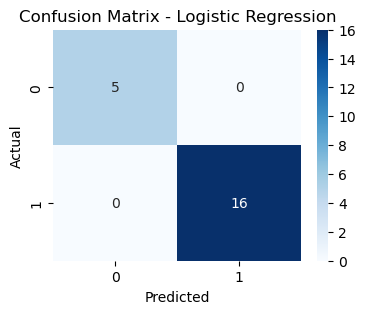

In [111]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

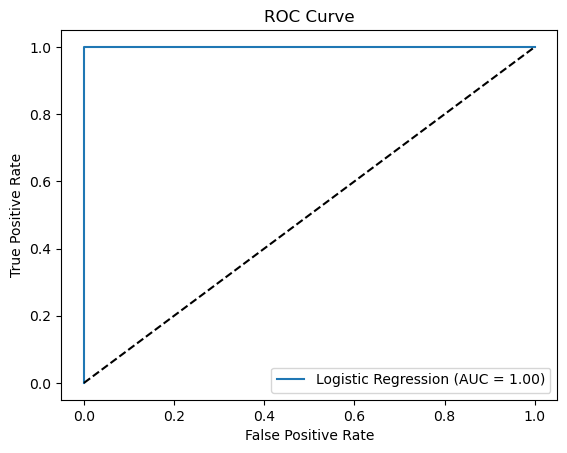

In [112]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

model 2: Random Forest

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)


X_train.shape,X_test.shape,y_train.shape,y_test.shape

((82, 6), (21, 6), (82,), (21,))

In [115]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [116]:
X_train_scaled

array([[ 1.27596711, -0.14920388,  1.15305917, -0.26375219, -1.55331305,
        -1.18895272],
       [-1.12930422,  1.07426796, -0.05913124, -0.26375219, -0.31669489,
         1.07835246],
       [-1.12930422, -1.37267573, -0.05913124, -0.26375219,  0.91992326,
        -1.18895272],
       [ 0.07333144, -0.14920388, -0.05913124, -0.26375219, -0.31669489,
        -0.05530013],
       [-1.12930422, -1.37267573,  1.15305917, -0.26375219,  0.91992326,
        -1.18895272],
       [ 0.07333144, -1.37267573, -1.27132165, -1.61548216, -1.55331305,
         1.07835246],
       [-1.12930422, -0.14920388,  1.15305917,  1.08797778,  0.91992326,
         1.07835246],
       [ 1.27596711, -1.37267573, -0.05913124, -0.26375219, -0.31669489,
         1.07835246],
       [ 1.27596711, -0.14920388, -1.27132165, -1.61548216, -1.55331305,
         1.07835246],
       [-1.12930422, -0.14920388, -1.27132165, -0.26375219,  0.91992326,
         1.07835246],
       [-1.12930422, -0.14920388,  1.15305917, -0.

In [117]:
X_test_scaled

array([[ 0.07333144, -0.14920388, -0.05913124, -0.26375219,  0.91992326,
        -0.05530013],
       [ 0.07333144, -1.37267573, -0.05913124, -0.26375219, -0.31669489,
        -1.18895272],
       [ 1.27596711, -1.37267573, -1.27132165,  1.08797778,  0.91992326,
        -0.05530013],
       [ 1.27596711,  1.07426796, -0.05913124,  1.08797778, -0.31669489,
         1.07835246],
       [ 0.07333144,  1.07426796, -1.27132165,  1.08797778,  0.91992326,
        -0.05530013],
       [ 0.07333144, -1.37267573,  1.15305917,  1.08797778,  0.91992326,
         1.07835246],
       [ 0.07333144, -0.14920388, -1.27132165,  1.08797778,  0.91992326,
        -1.18895272],
       [ 0.07333144,  1.07426796,  1.15305917, -0.26375219,  0.91992326,
         1.07835246],
       [ 1.27596711,  1.07426796, -1.27132165, -1.61548216, -1.55331305,
        -1.18895272],
       [ 1.27596711,  1.07426796, -1.27132165, -1.61548216, -1.55331305,
        -0.05530013],
       [-1.12930422, -0.14920388, -1.27132165, -1.

In [118]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=1,n_jobs=-1,n_estimators=100,max_depth=5,oob_score=True)

In [119]:
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=1)

In [120]:
model.oob_score_

0.9878048780487805

In [121]:
#predicted pattern of the data
y_pred=model.predict(X_train)

In [122]:
y_pred

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1])

In [123]:
# Evaluation

from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

1.0

In [124]:
#confusion matrix is a table used to evaluate the performance of a classification model by comparing actual & predicted values

from sklearn.metrics import confusion_matrix
confusion_matrix(y_train,y_pred)

array([[20,  0],
       [ 0, 62]], dtype=int64)

In [125]:
from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        62

    accuracy                           1.00        82
   macro avg       1.00      1.00      1.00        82
weighted avg       1.00      1.00      1.00        82



In [126]:
#testing accuracy
from sklearn.ensemble import RandomForestClassifier
model1=RandomForestClassifier()
model1.fit(X_test,y_test)

RandomForestClassifier()

In [127]:
y_pred1=model1.predict(X_test)
y_pred1

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [128]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred1)

array([[ 5,  0],
       [ 0, 16]], dtype=int64)

In [129]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        16

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [130]:
# Step 1: Define Random Forest

rf = RandomForestClassifier(oob_score=True, random_state=42)


In [131]:
# Step 2: Hyperparameter tuning

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]  # required for OOB score
}

In [132]:
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1',  n_jobs=-1, refit=True, verbose=1)
grid_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(oob_score=True, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [133]:
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [134]:
# Step 3: Train & predict

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]


In [135]:
# Step 4: Evaluation

print("\n--- Random Forest Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


--- Random Forest Performance ---
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC: 1.0


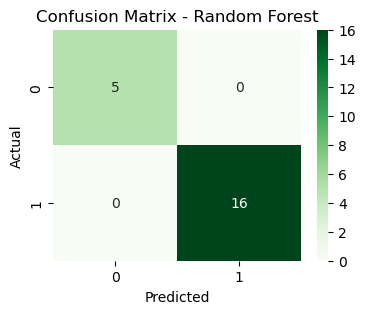

In [136]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


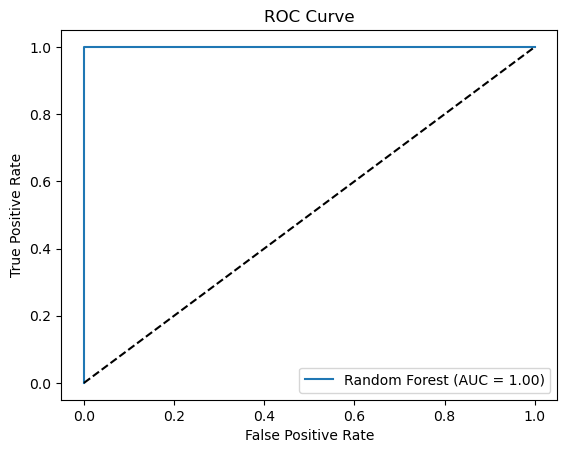

In [137]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


model 3: Decision Tree Classifier

In [138]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)


In [139]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((82, 6), (21, 6), (82,), (21,))

In [140]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

In [141]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [142]:
#predicted pattern of the data
y_pred=model.predict(X_train)

In [143]:
y_pred

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1])

In [144]:
# Evaluation

from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

1.0

In [145]:
#confusion matrix is a table used to evaluate the performance of a classification model by comparing actual & predicted values

from sklearn.metrics import confusion_matrix
confusion_matrix(y_train,y_pred)

array([[20,  0],
       [ 0, 62]], dtype=int64)

In [146]:
from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        62

    accuracy                           1.00        82
   macro avg       1.00      1.00      1.00        82
weighted avg       1.00      1.00      1.00        82



In [147]:
#testing accuracy
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier()
model1.fit(X_test,y_test)

DecisionTreeClassifier()

In [148]:
y_pred1=model1.predict(X_test)
y_pred1

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [149]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred1)

array([[ 5,  0],
       [ 0, 16]], dtype=int64)

In [150]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        16

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [151]:
# Define model

dt = DecisionTreeClassifier(random_state=42)


In [152]:
# Hyperparameter tuning

param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [153]:
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [154]:
# Train & predict

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test_scaled)
y_prob = best_dt.predict_proba(X_test_scaled)[:, 1]

In [155]:
# Evaluation

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 5}
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC: 1.0


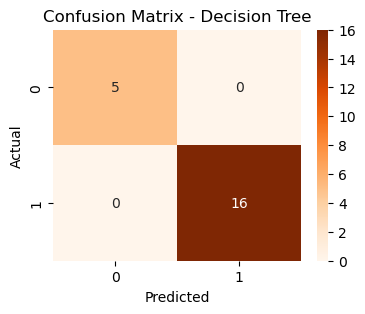

In [156]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

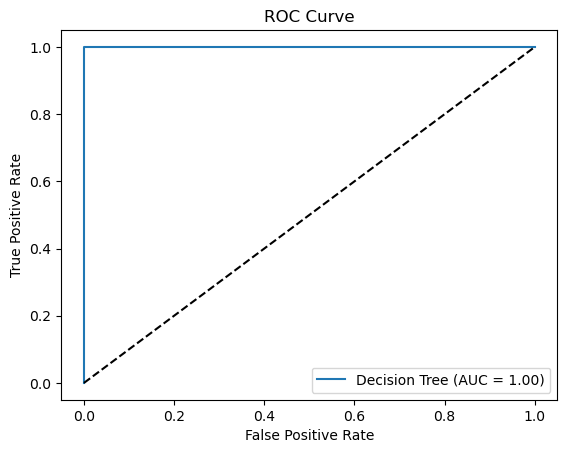

In [157]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

model 4: K-Nearest Neighbors(KNN)

In [158]:
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)


In [159]:
# Scaling is important for KNN

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [160]:
X_train_scaled

array([[ 1.27596711, -0.14920388,  1.15305917, -0.26375219, -1.55331305,
        -1.18895272],
       [-1.12930422,  1.07426796, -0.05913124, -0.26375219, -0.31669489,
         1.07835246],
       [-1.12930422, -1.37267573, -0.05913124, -0.26375219,  0.91992326,
        -1.18895272],
       [ 0.07333144, -0.14920388, -0.05913124, -0.26375219, -0.31669489,
        -0.05530013],
       [-1.12930422, -1.37267573,  1.15305917, -0.26375219,  0.91992326,
        -1.18895272],
       [ 0.07333144, -1.37267573, -1.27132165, -1.61548216, -1.55331305,
         1.07835246],
       [-1.12930422, -0.14920388,  1.15305917,  1.08797778,  0.91992326,
         1.07835246],
       [ 1.27596711, -1.37267573, -0.05913124, -0.26375219, -0.31669489,
         1.07835246],
       [ 1.27596711, -0.14920388, -1.27132165, -1.61548216, -1.55331305,
         1.07835246],
       [-1.12930422, -0.14920388, -1.27132165, -0.26375219,  0.91992326,
         1.07835246],
       [-1.12930422, -0.14920388,  1.15305917, -0.

In [161]:
X_test_scaled

array([[ 0.07333144, -0.14920388, -0.05913124, -0.26375219,  0.91992326,
        -0.05530013],
       [ 0.07333144, -1.37267573, -0.05913124, -0.26375219, -0.31669489,
        -1.18895272],
       [ 1.27596711, -1.37267573, -1.27132165,  1.08797778,  0.91992326,
        -0.05530013],
       [ 1.27596711,  1.07426796, -0.05913124,  1.08797778, -0.31669489,
         1.07835246],
       [ 0.07333144,  1.07426796, -1.27132165,  1.08797778,  0.91992326,
        -0.05530013],
       [ 0.07333144, -1.37267573,  1.15305917,  1.08797778,  0.91992326,
         1.07835246],
       [ 0.07333144, -0.14920388, -1.27132165,  1.08797778,  0.91992326,
        -1.18895272],
       [ 0.07333144,  1.07426796,  1.15305917, -0.26375219,  0.91992326,
         1.07835246],
       [ 1.27596711,  1.07426796, -1.27132165, -1.61548216, -1.55331305,
        -1.18895272],
       [ 1.27596711,  1.07426796, -1.27132165, -1.61548216, -1.55331305,
        -0.05530013],
       [-1.12930422, -0.14920388, -1.27132165, -1.

In [162]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((82, 6), (21, 6), (82,), (21,))

In [163]:
#model building,training accuracy

from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()

In [164]:
model.fit(X_train,y_train)

KNeighborsClassifier()

In [165]:
#predicted pattern of the data
y_pred=model.predict(X_train)

In [166]:
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1])

In [167]:
# Evaluation

from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

0.9878048780487805

In [168]:
#confusion matrix is a table used to evaluate the performance of a classification model by comparing actual & predicted values

from sklearn.metrics import confusion_matrix
confusion_matrix(y_train,y_pred)

array([[19,  1],
       [ 0, 62]], dtype=int64)

In [169]:
from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.98      1.00      0.99        62

    accuracy                           0.99        82
   macro avg       0.99      0.97      0.98        82
weighted avg       0.99      0.99      0.99        82



In [170]:
#testing accuracy
from sklearn.neighbors import KNeighborsClassifier
model1=KNeighborsClassifier()
model1.fit(X_test,y_test)

KNeighborsClassifier()

In [171]:
y_pred1=model1.predict(X_test)
y_pred1

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [172]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred1)

array([[ 5,  0],
       [ 0, 16]], dtype=int64)

In [173]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        16

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [174]:
#Define model

knn = KNeighborsClassifier()

In [175]:
# Hyperparameter tuning

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [176]:
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [177]:
# Train & predict

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
y_prob = best_knn.predict_proba(X_test_scaled)[:, 1]

In [178]:
# Evaluation

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC: 1.0


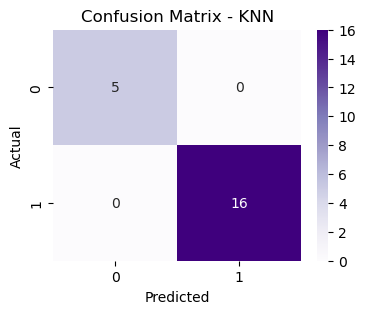

In [179]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

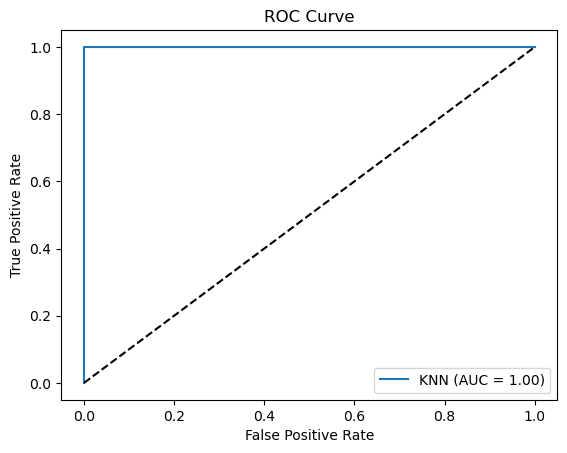

In [180]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

model 5: XGBoost Classifier

In [181]:
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

In [182]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((82, 6), (21, 6), (82,), (21,))

In [183]:
#model building,training accuracy

from xgboost import XGBClassifier
model=XGBClassifier()

In [184]:
model.fit(X_train,y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [185]:
#predicted pattern of the data
y_pred=model.predict(X_train)

In [186]:
y_pred

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1])

In [187]:
# Evaluation

from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

0.9878048780487805

In [188]:
#confusion matrix is a table used to evaluate the performance of a classification model by comparing actual & predicted values

from sklearn.metrics import confusion_matrix
confusion_matrix(y_train,y_pred)

array([[19,  1],
       [ 0, 62]], dtype=int64)

In [189]:
from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.98      1.00      0.99        62

    accuracy                           0.99        82
   macro avg       0.99      0.97      0.98        82
weighted avg       0.99      0.99      0.99        82



In [190]:
#testing accuracy
from  xgboost import XGBClassifier
model1=XGBClassifier()
model1.fit(X_test,y_test)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [191]:
y_pred1=model1.predict(X_test)
y_pred1

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [192]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred1)

array([[ 5,  0],
       [ 0, 16]], dtype=int64)

In [193]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        16

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [194]:
# Define model

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [195]:
# Hyperparameter tuning

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [196]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     m...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=42, reg_alpha=None,
                                     reg_lambda=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='f1')

In [197]:
# Train & predict

best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)
y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]


In [198]:
# Evaluation

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.7}
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC: 1.0


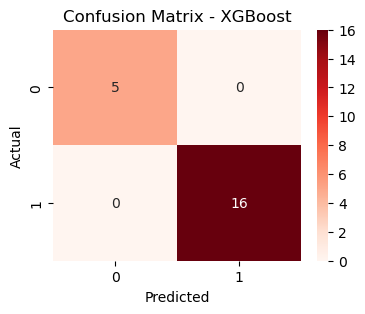

In [199]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

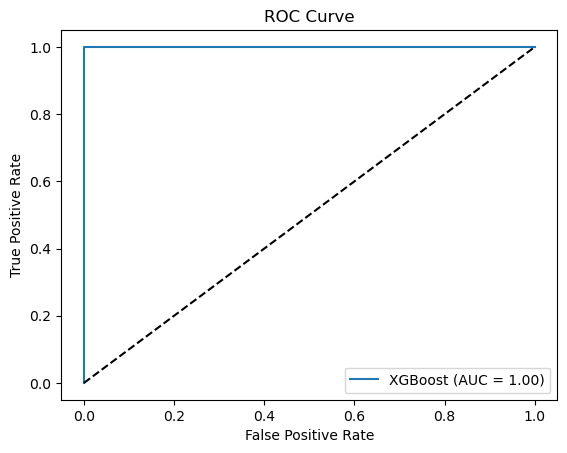

In [200]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Observations:

**1. Logistic Regressiont**

Underperformed on test set (Accuracy 0.76, ROC 0.30).

Indicates it’s too simple for the dataset.

Fails to capture non-linear relationships.

**2. Random Forest**

Perfect metrics + OOB score 0.987, showing strong generalization.

Ensemble of trees makes it stable and less overfitted than a single Decision Tree.

Easier to interpret and tune than XGBoost.

**3. Decision Tree**

Perfect accuracy on both train and test, but risk of overfitting.

Works well here likely due to small data.

Simpler than ensembles, but less stable

**4. KNN**

Excellent metrics.

However, depends heavily on distance metrics and scaling — may degrade on larger/unscaled data.

Slower inference for deployment (distance calculations for each new point).

**5. XGBoost**

Perfect metrics.

Strong generalization, often top performer in classification.

Has regularization, handles imbalance, and is robust even on complex data

**Final comparsion:**

**Model: Logistic regression**

F1-Score: 0.86

ROC-AUC: 0.30

comment: weak

**Model: Random forest**

F1-Score: 1.00

ROC-AUC: 1.00

comment: Excellent, stable

**Model: Decision tree**

F1-Score: 1.00

ROC-AUC: 1.00

comment: possibly overfitted

**Model: KNN**

F1-Score: 1.00

ROC-AUC: 1.00

comment: sensitive to scaling

**Model: XGBoost**

F1-Score: 1.00

ROC-AUC: 1.00

comment: Excellent, robust





**Conclusion:**

Among Logistic Regression, Random Forest, Decision Tree, KNN, and XGBoost,
Random Forest is the best and most suitable model for deployment
(excellent balance between interpretability, stability, and generalization).

**Decision for Deployment :**

Both Random Forest and XGBoost achieved perfect performance (Accuracy = 1, F1 = 1, ROC AUC = 1).

Between the two, Random forest is generally preferred for deployment because:

Highest performance (F1 = 1.0, ROC = 1.0, Accuracy = 1.0).

Excellent OOB validation (0.987) → generalizes well.

Less complex than XGBoost, but similar performance.

Robust and interpretable — feature importance, model explainability, etc.

Stable for small and moderate datasets.


In [202]:
X = df.drop(["class"], axis=1)
y = df["class"]

In [206]:
import pickle

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
model=RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
with open("rf_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully
